In [2]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings, json, os
warnings.filterwarnings("ignore")

# ── Numerical / data ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Notebook-friendly inline rendering
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
PALETTE = ["#2E5FA3", "#E8813A", "#1D9E75", "#C44E52", "#8172B2", "#64B5CD"]
sns.set_palette(PALETTE)

# ── Machine learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LinearRegression, Ridge, Lasso
from sklearn.ensemble       import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline       import Pipeline
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

# ── Time-series ──────────────────────────────────────────────────────────────
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

print("All libraries loaded successfully.")
print(f"pandas {pd.__version__}  |  numpy {np.__version__}  |  xgboost {xgb.__version__}")


All libraries loaded successfully.
pandas 2.3.3  |  numpy 2.3.5  |  xgboost 3.2.0


In [3]:
np.random.seed(42)

quarters = pd.date_range("2015-01-01", "2024-10-01", freq="QS")
n        = len(quarters)   # 40 quarters

# ── Production (exponential ramp + small white noise) ────────────────────────
production_base = np.linspace(11_000, 470_000, n)
production      = (production_base * (1 + np.random.normal(0, 0.04, n))).astype(int)

# ── Deliveries (≈ production minus a small inventory build) ─────────────────
deliveries = (production * np.random.uniform(0.93, 1.00, n)).astype(int)

# ── Revenue ($B) = deliveries × average selling price ───────────────────────
avg_price_k = np.linspace(85, 47, n) + np.random.normal(0, 2, n)
revenue_b   = deliveries * avg_price_k * 1_000 / 1e9

# ── Stock price (secular trend + 2 full boom-bust cycles + noise) ───────────
stock_price = np.clip(
    np.linspace(15, 250, n)
    + 30 * np.sin(np.linspace(0, 4 * np.pi, n))
    + np.random.normal(0, 12, n),
    10, 420
)

# ── Model mix percentages ────────────────────────────────────────────────────
model_3y_pct = np.clip(np.linspace(0, 55, n) + np.random.normal(0, 3, n), 0, 60)
model_xy_pct = np.clip(np.linspace(0, 30, n) + np.random.normal(0, 2, n), 0, 35)
model_s_pct  = np.clip(100 - model_3y_pct - model_xy_pct + np.random.normal(0, 2, n), 5, 100)

# ── Macro ────────────────────────────────────────────────────────────────────
interest_rate = np.linspace(0.25, 5.5, n) + np.random.normal(0, 0.2, n)
ev_market_pct = np.linspace(0.5, 22, n)

df = pd.DataFrame({
    "year":           quarters.year,
    "quarter":        quarters.quarter,
    "production":     production,
    "deliveries":     deliveries,
    "revenue_b":      revenue_b.round(3),
    "avg_price_k":    avg_price_k.round(1),
    "stock_price":    stock_price.round(2),
    "model_3y_pct":   model_3y_pct.round(1),
    "model_xy_pct":   model_xy_pct.round(1),
    "model_s_pct":    model_s_pct.round(1),
    "interest_rate":  interest_rate.round(2),
    "ev_market_pct":  ev_market_pct.round(2),
}, index=quarters)
df.index.name = "date"

print(f"Shape: {df.shape}  →  {df.shape[0]} quarters × {df.shape[1]} features")
print("\nDate range:", df.index[0].date(), "→", df.index[-1].date())
print("\nFirst 5 rows:")
df.head()


Shape: (40, 12)  →  40 quarters × 12 features

Date range: 2015-01-01 → 2024-10-01

First 5 rows:


,year,quarter,production,deliveries,revenue_b,avg_price_k,stock_price,model_3y_pct,model_xy_pct,model_s_pct,interest_rate,ev_market_pct
date,,,,,,,,,,,,
2015-01-01,2015,1,11218,11194,0.960,85.7,18.09,1.6,0.0,97.0,0.16,0.50
2015-04-01,2015,2,22643,22286,1.844,82.7,29.63,2.3,0.0,99.1,0.41,1.05
2015-07-01,2015,3,35433,35282,2.956,83.8,22.05,3.6,0.6,94.3,0.81,1.60
2015-10-01,2015,4,49128,48766,4.153,85.2,57.45,5.3,4.0,91.1,0.37,2.15
2016-01-01,2016,1,57532,55912,4.531,81.0,68.64,3.6,3.5,93.0,1.02,2.71


In [4]:
# ── 2.1  Missing values ──────────────────────────────────────────────────────
print("=== Missing Values ===")
print(f"  Nulls before fill: {df.isnull().sum().sum()}")
df.ffill(inplace=True)
print(f"  Nulls after fill:  {df.isnull().sum().sum()}")

# ── 2.2  IQR outlier detection ───────────────────────────────────────────────
print("\n=== IQR Outlier Detection (k=2.5) ===")
def flag_outliers(series, k=2.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr    = q3 - q1
    return int(((series < q1 - k * iqr) | (series > q3 + k * iqr)).sum())

for col in ["production", "deliveries", "revenue_b", "avg_price_k", "stock_price"]:
    n_out = flag_outliers(df[col])
    flag  = "  ⚠" if n_out > 0 else "  ✓"
    print(f"  {col:<18}: {n_out} outlier(s){flag}")

# ── 2.3  dtypes ──────────────────────────────────────────────────────────────
print("\n=== Data Types ===")
print(df.dtypes.to_string())

# ── 2.4  Basic statistics ────────────────────────────────────────────────────
print("\n=== Descriptive Statistics ===")
df.describe().round(2)


=== Missing Values ===
  Nulls before fill: 0
  Nulls after fill:  0

=== IQR Outlier Detection (k=2.5) ===
  production        : 0 outlier(s)  ✓
  deliveries        : 0 outlier(s)  ✓
  revenue_b         : 0 outlier(s)  ✓
  avg_price_k       : 0 outlier(s)  ✓
  stock_price       : 0 outlier(s)  ✓

=== Data Types ===
year               int32
quarter            int32
production         int64
deliveries         int64
revenue_b        float64
avg_price_k      float64
stock_price      float64
model_3y_pct     float64
model_xy_pct     float64
model_s_pct      float64
interest_rate    float64
ev_market_pct    float64

=== Descriptive Statistics ===


,year,quarter,production,deliveries,revenue_b,avg_price_k,stock_price,model_3y_pct,model_xy_pct,model_s_pct,interest_rate,ev_market_pct
count,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
mean,2019.50,2.50,237115.82,228565.22,13.60,65.90,131.87,28.20,15.26,56.34,2.89,11.25
std,2.91,1.13,135352.02,130868.92,6.16,11.62,64.59,16.75,9.26,26.13,1.60,6.44
min,2015.00,1.00,11218.00,11194.00,0.96,47.30,18.09,1.60,0.00,12.50,0.16,0.50
25%,2017.00,1.75,124594.50,119130.25,8.99,55.80,78.14,14.08,6.95,35.72,1.55,5.87
50%,2019.50,2.50,238591.50,231314.50,15.34,66.35,131.80,27.70,16.00,54.10,2.94,11.25
75%,2022.00,3.25,349976.25,332962.50,18.62,74.58,187.56,42.12,22.15,78.25,4.26,16.63
max,2024.00,4.00,473700.00,456199.00,22.28,85.70,234.15,55.00,30.60,99.10,5.62,22.00


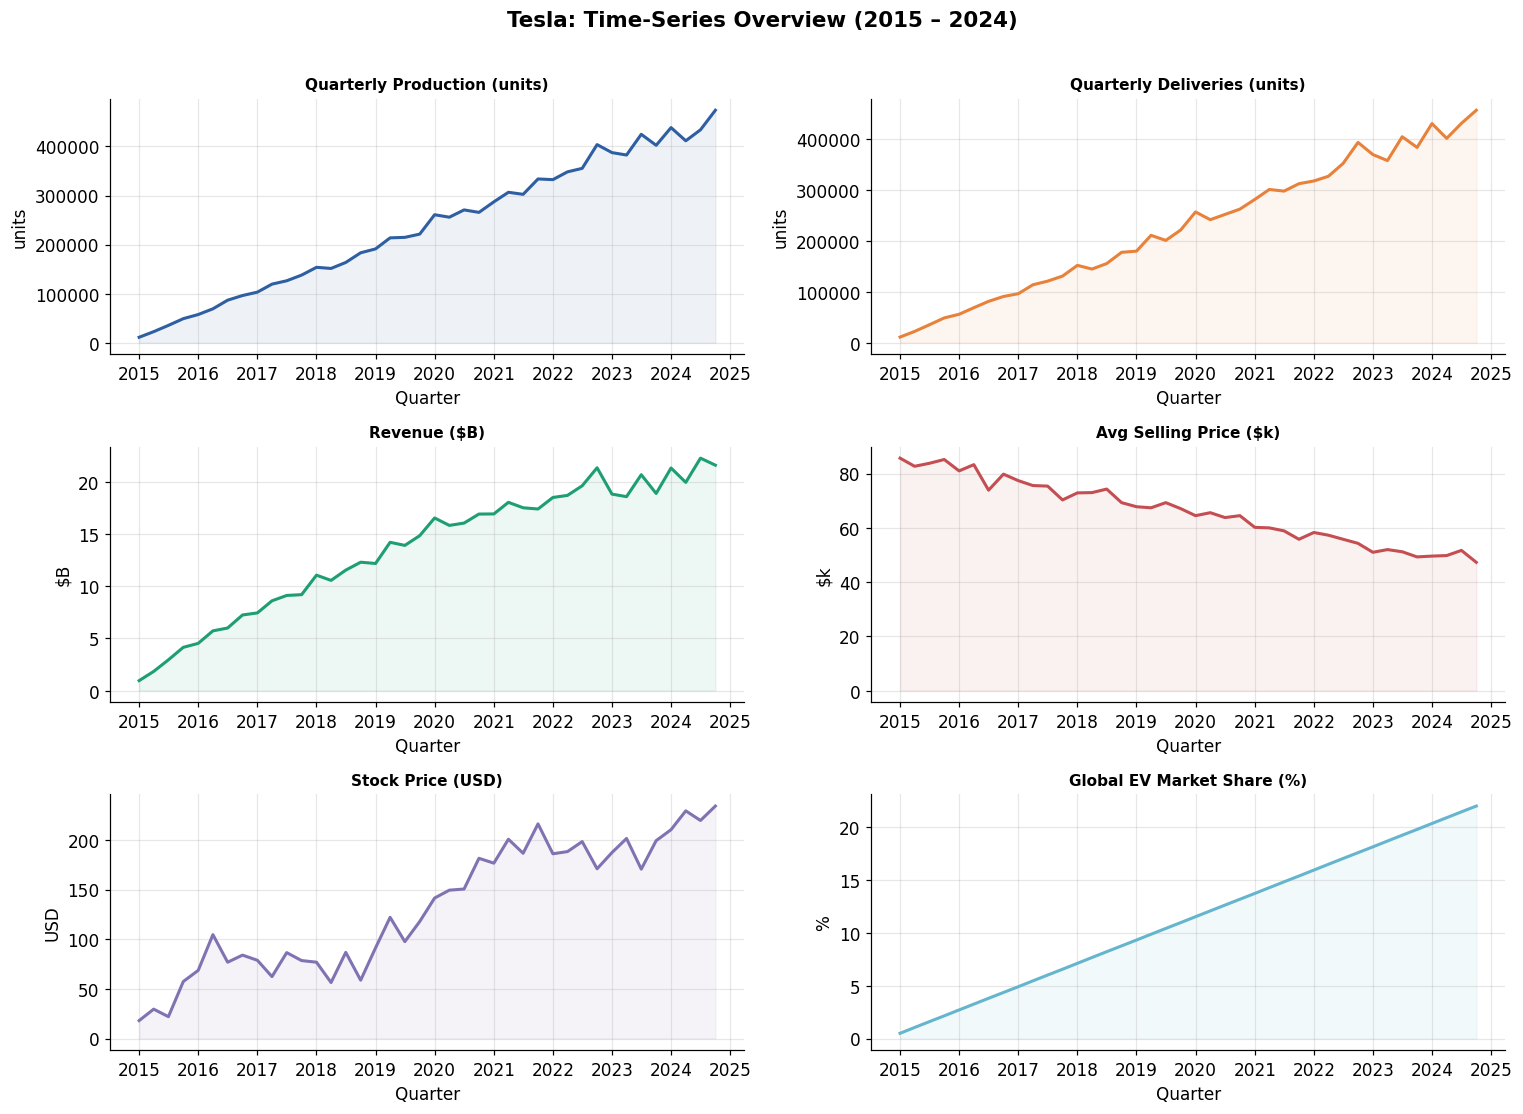

Saved: eda_timeseries.png


In [5]:
# ── 3.1  Time-series overview: 6 KPIs ───────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Tesla: Time-Series Overview (2015 – 2024)", fontsize=14, fontweight="bold", y=1.01)

kpi_specs = [
    ("production",    "Quarterly Production (units)",  "#2E5FA3"),
    ("deliveries",    "Quarterly Deliveries (units)",  "#E8813A"),
    ("revenue_b",     "Revenue ($B)",                  "#1D9E75"),
    ("avg_price_k",   "Avg Selling Price ($k)",        "#C44E52"),
    ("stock_price",   "Stock Price (USD)",             "#8172B2"),
    ("ev_market_pct", "Global EV Market Share (%)",   "#64B5CD"),
]

for ax, (col, title, color) in zip(axes.flat, kpi_specs):
    ax.plot(df.index, df[col], color=color, linewidth=2)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel(title.split("(")[-1].replace(")", "") if "(" in title else "")
    ax.fill_between(df.index, df[col], alpha=0.08, color=color)

plt.tight_layout()
plt.savefig("eda_timeseries.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_timeseries.png")


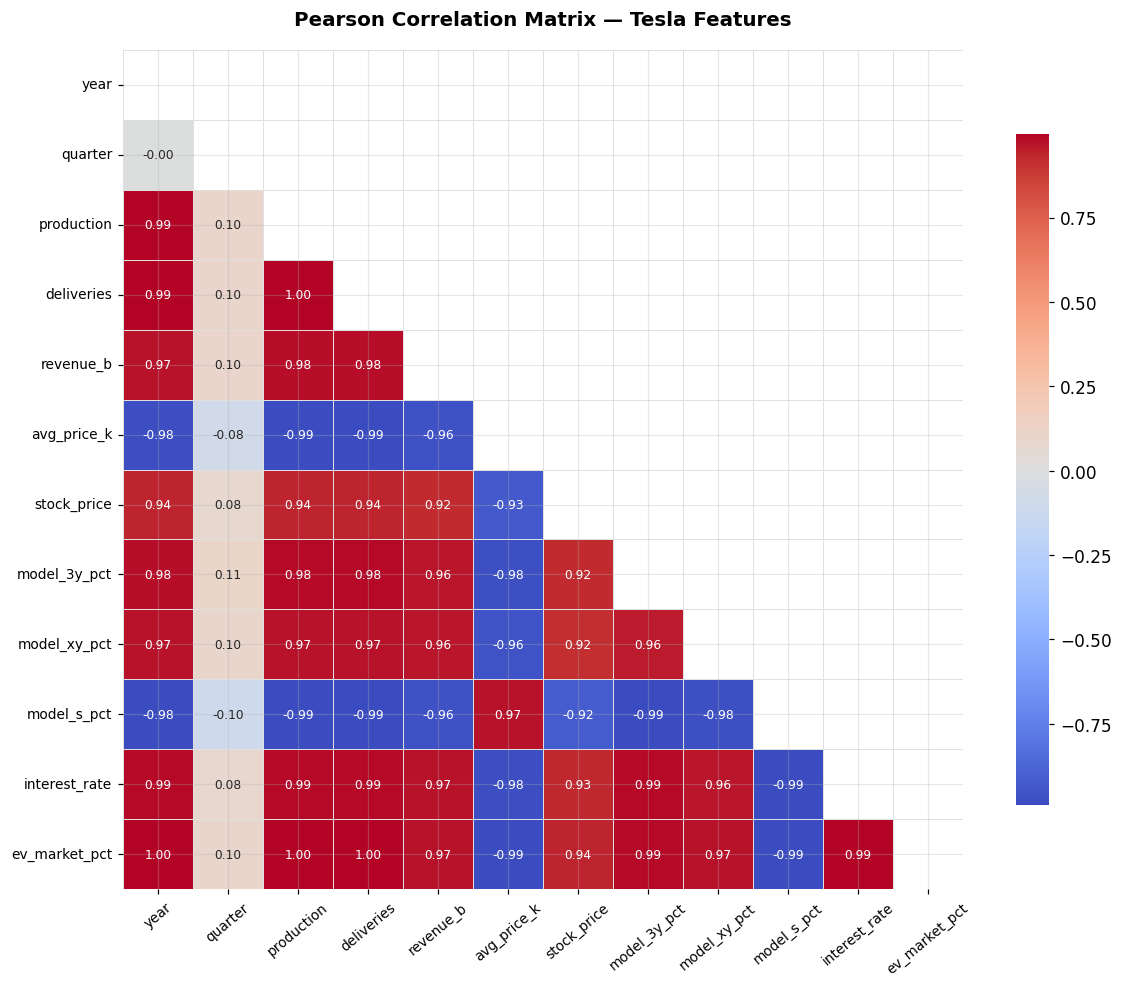

Saved: eda_correlation.png


In [6]:
# ── 3.2  Correlation heat-map ────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.4, linecolor="#e0e0e0",
    square=True, ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Pearson Correlation Matrix — Tesla Features", fontsize=13, fontweight="bold", pad=16)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_correlation.png")


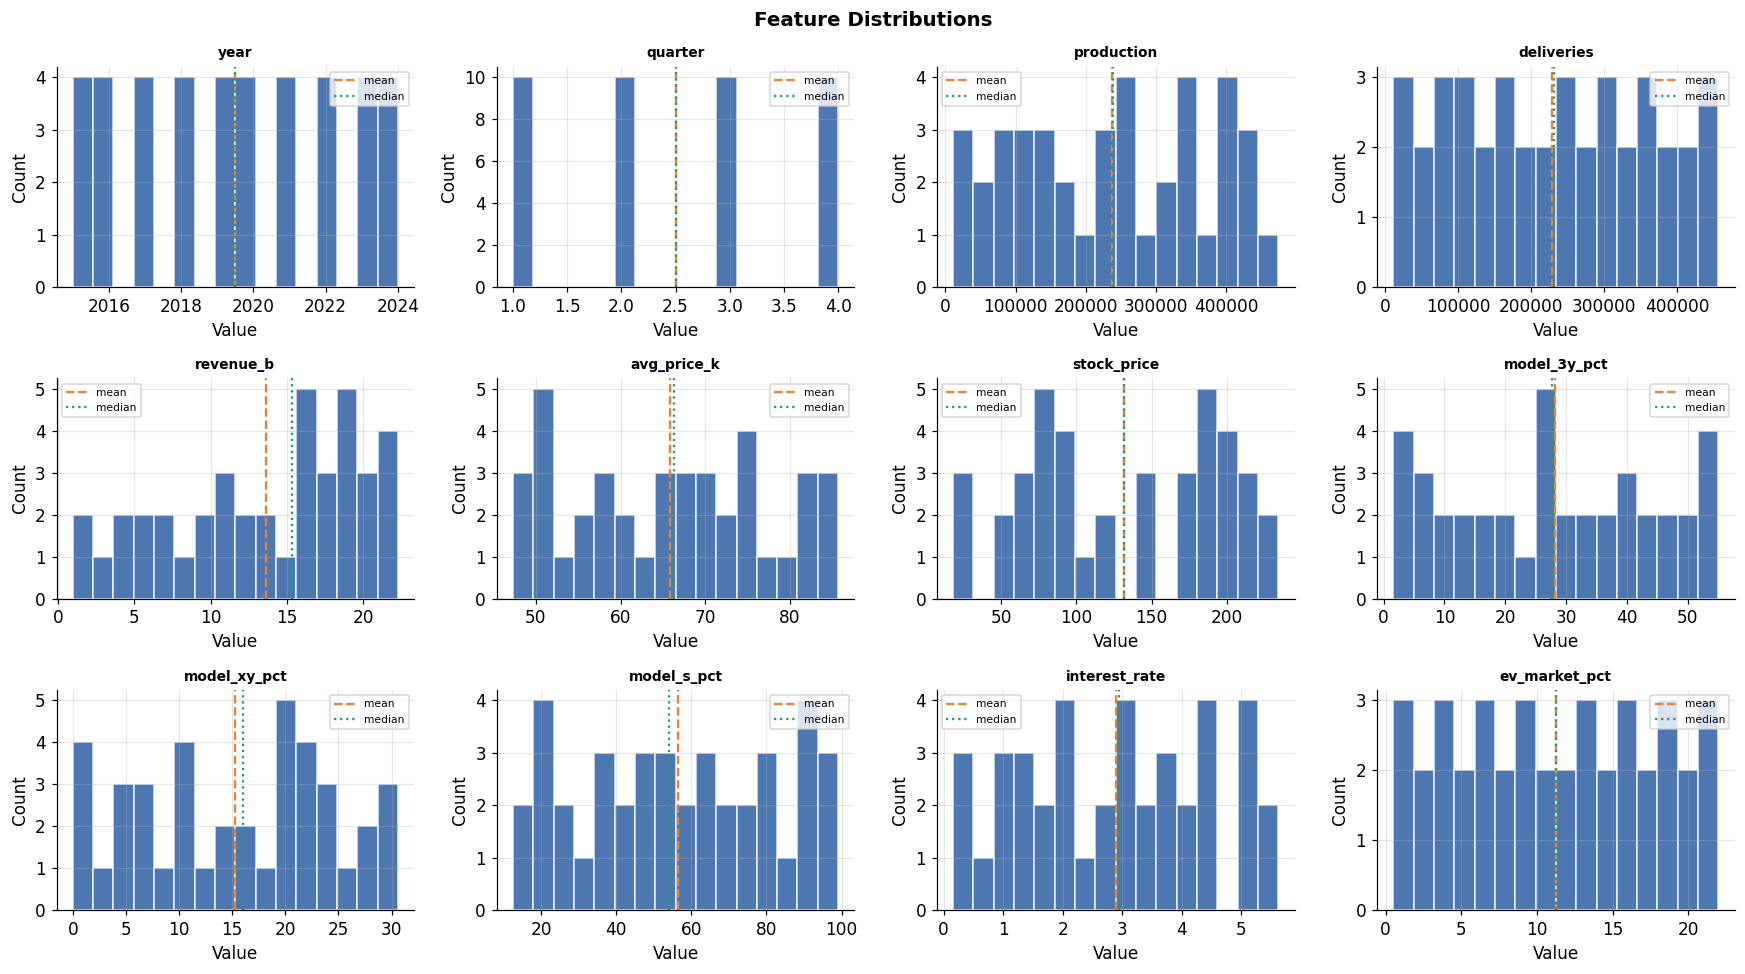

Saved: eda_distributions.png


In [7]:
# ── 3.3  Feature distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
fig.suptitle("Feature Distributions", fontsize=13, fontweight="bold")
cols = numeric_df.columns.tolist()

for ax, col in zip(axes.flat, cols):
    data = numeric_df[col].dropna()
    ax.hist(data, bins=16, color="#2E5FA3", edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="#E8813A", linewidth=1.5, linestyle="--", label="mean")
    ax.axvline(data.median(), color="#1D9E75", linewidth=1.5, linestyle=":",  label="median")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

# hide any unused subplots
for ax in axes.flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eda_distributions.png")


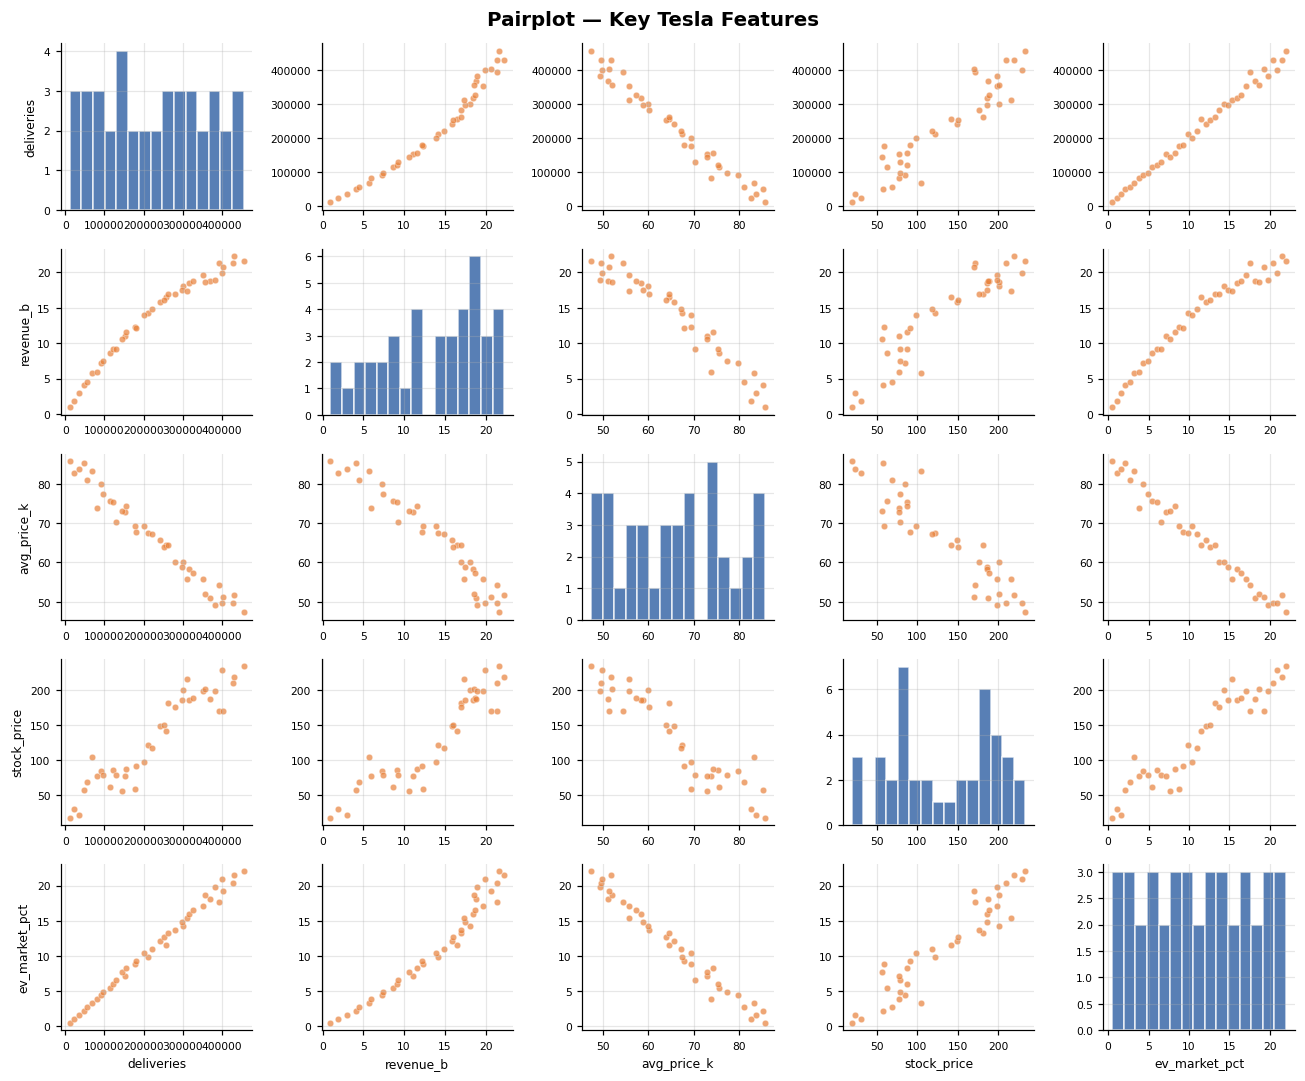

Saved: eda_pairplot.png


In [8]:
# ── 3.4  Scatter matrix (key features) ──────────────────────────────────────
key_cols = ["deliveries", "revenue_b", "avg_price_k", "stock_price", "ev_market_pct"]
pair_df  = numeric_df[key_cols].copy()

fig = plt.figure(figsize=(12, 10))
fig.suptitle("Pairplot — Key Tesla Features", fontsize=13, fontweight="bold")
axes = fig.subplots(len(key_cols), len(key_cols))

for i, row_col in enumerate(key_cols):
    for j, col_col in enumerate(key_cols):
        ax = axes[i][j]
        if i == j:
            ax.hist(pair_df[row_col], bins=15, color="#2E5FA3", edgecolor="white", alpha=0.8)
        else:
            ax.scatter(pair_df[col_col], pair_df[row_col],
                       s=18, alpha=0.7, color="#E8813A", edgecolors="white", linewidths=0.3)
        if j == 0:
            ax.set_ylabel(row_col, fontsize=8)
        if i == len(key_cols) - 1:
            ax.set_xlabel(col_col, fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("eda_pairplot.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: eda_pairplot.png")


In [9]:
fe = df.copy()

# ── 4.1  Lag features ────────────────────────────────────────────────────────
for col in ["production", "deliveries", "revenue_b", "stock_price"]:
    fe[f"{col}_lag1"] = fe[col].shift(1)
    fe[f"{col}_lag2"] = fe[col].shift(2)

# ── 4.2  Rolling statistics (4-quarter window) ───────────────────────────────
for col in ["production", "deliveries"]:
    fe[f"{col}_roll4_mean"] = fe[col].rolling(4).mean()
    fe[f"{col}_roll4_std"]  = fe[col].rolling(4).std()

# ── 4.3  Year-over-year growth rates ─────────────────────────────────────────
fe["delivery_growth_yoy"] = fe["deliveries"].pct_change(4) * 100
fe["revenue_growth_yoy"]  = fe["revenue_b"].pct_change(4)  * 100

# ── 4.4  Efficiency ratio ────────────────────────────────────────────────────
fe["delivery_efficiency"] = fe["deliveries"] / fe["production"]

# ── 4.5  Time & Fourier seasonality features ─────────────────────────────────
fe["t"]     = np.arange(len(fe))                          # linear time index
fe["q_sin"] = np.sin(2 * np.pi * fe["quarter"] / 4)      # seasonal sine
fe["q_cos"] = np.cos(2 * np.pi * fe["quarter"] / 4)      # seasonal cosine

# ── 4.6  Target: next-quarter deliveries ─────────────────────────────────────
fe["target_deliveries"] = fe["deliveries"].shift(-1)

# Drop rows with NaN (from lags and the final target row)
fe.dropna(inplace=True)
fe.reset_index(inplace=True)

print(f"Shape after feature engineering: {fe.shape}")
print(f"  → {fe.shape[0]} usable rows, {fe.shape[1]} columns (features + target)")
print("\nNew feature columns added:")
new_cols = [c for c in fe.columns if any(
    s in c for s in ["lag", "roll", "growth", "efficiency", "q_sin", "q_cos", "target", "^t$"]
) or c == "t"]
print("  " + ", ".join(new_cols))
fe.tail(3)


Shape after feature engineering: (35, 32)
  → 35 usable rows, 32 columns (features + target)

New feature columns added:
  production_lag1, production_lag2, deliveries_lag1, deliveries_lag2, revenue_b_lag1, revenue_b_lag2, stock_price_lag1, stock_price_lag2, production_roll4_mean, production_roll4_std, deliveries_roll4_mean, deliveries_roll4_std, delivery_growth_yoy, revenue_growth_yoy, delivery_efficiency, t, q_sin, q_cos, target_deliveries


,date,year,quarter,production,deliveries,revenue_b,avg_price_k,stock_price,model_3y_pct,model_xy_pct,...,production_roll4_std,deliveries_roll4_mean,deliveries_roll4_std,delivery_growth_yoy,revenue_growth_yoy,delivery_efficiency,t,q_sin,q_cos,target_deliveries
32,2024-01-01,2024,1,438323,430026,21.330,49.6,210.35,50.1,26.7,...,24626.434840,393726.25,30850.741800,16.455840,13.282702,0.981071,36,1.000000e+00,6.123234e-17,401024.0
33,2024-04-01,2024,2,411464,401024,19.954,49.8,229.31,54.3,30.6,...,15728.955517,404628.75,19274.546590,12.201537,7.354603,0.974627,37,1.224647e-16,-1.000000e+00,430460.0
34,2024-07-01,2024,3,433886,430460,22.275,51.7,219.63,55.0,29.4,...,17387.157222,411194.25,23160.089297,6.497311,7.665909,0.992104,38,-1.000000e+00,-1.836970e-16,456199.0


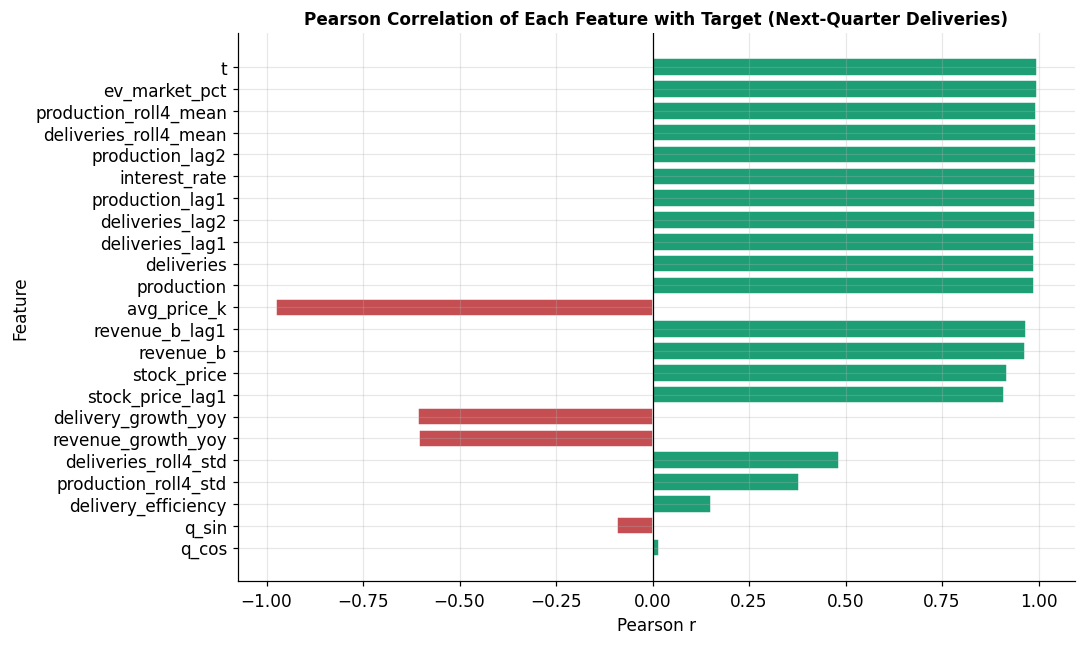

Saved: feature_target_correlation.png

Top 5 predictors:
t                        0.995
ev_market_pct            0.995
production_roll4_mean    0.993
deliveries_roll4_mean    0.993
production_lag2          0.992


In [10]:
# ── 4.7  Feature importance preview via correlation with target ───────────────
FEATURES = [
    "production", "deliveries", "revenue_b", "avg_price_k",
    "stock_price", "interest_rate", "ev_market_pct",
    "production_lag1", "production_lag2",
    "deliveries_lag1", "deliveries_lag2",
    "revenue_b_lag1",  "stock_price_lag1",
    "production_roll4_mean", "deliveries_roll4_mean",
    "production_roll4_std",  "deliveries_roll4_std",
    "delivery_growth_yoy",   "revenue_growth_yoy",
    "delivery_efficiency",   "t", "q_sin", "q_cos",
]
TARGET = "target_deliveries"

corr_with_target = (
    fe[FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1D9E75" if v > 0 else "#C44E52" for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Each Feature with Target (Next-Quarter Deliveries)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Pearson r")
ax.set_ylabel("Feature")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("feature_target_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: feature_target_correlation.png")
print(f"\nTop 5 predictors:\n{corr_with_target.head(5).round(3).to_string()}")


In [11]:
X = fe[FEATURES].values
y = fe[TARGET].values

# Chronological split — no shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

# Scale features for linear models (tree models use raw arrays)
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)


Training samples : 28
Test samples     : 7
Features         : 23


In [12]:
def evaluate_model(name, model, Xtr, ytr, Xte, yte, cv_folds=3):
    """Fit model, evaluate on test set, run k-fold CV, return metrics dict."""
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    mae  = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    r2   = r2_score(yte, pred)
    cv_scores = cross_val_score(
        model, Xtr, ytr,
        cv=cv_folds, scoring="neg_mean_absolute_error"
    )
    cv_mae = -cv_scores.mean()
    return {
        "name": name, "model": model, "pred": pred,
        "mae": mae, "rmse": rmse, "r2": r2, "cv_mae": cv_mae,
    }

results = {}

# ── Linear Regression ────────────────────────────────────────────────────────
results["Linear"]     = evaluate_model("Linear Regression",    LinearRegression(),
                                       X_train_s, y_train, X_test_s, y_test)

# ── Ridge (L2) ───────────────────────────────────────────────────────────────
results["Ridge"]      = evaluate_model("Ridge (L2, α=10)",     Ridge(alpha=10),
                                       X_train_s, y_train, X_test_s, y_test)

# ── Lasso (L1) ───────────────────────────────────────────────────────────────
results["Lasso"]      = evaluate_model("Lasso (L1, α=5)",      Lasso(alpha=5, max_iter=5000),
                                       X_train_s, y_train, X_test_s, y_test)

# ── Random Forest ────────────────────────────────────────────────────────────
results["RF"]         = evaluate_model("Random Forest",        RandomForestRegressor(n_estimators=150, random_state=42),
                                       X_train, y_train, X_test, y_test)

# ── Gradient Boosting ────────────────────────────────────────────────────────
results["GB"]         = evaluate_model("Gradient Boosting",    GradientBoostingRegressor(n_estimators=150, random_state=42),
                                       X_train, y_train, X_test, y_test)

# ── XGBoost ──────────────────────────────────────────────────────────────────
results["XGB"]        = evaluate_model("XGBoost",              xgb.XGBRegressor(n_estimators=150, learning_rate=0.08,
                                       random_state=42, verbosity=0),
                                       X_train, y_train, X_test, y_test)

# ── Summary table ────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {"Model": v["name"], "MAE": v["mae"], "RMSE": v["rmse"], "R²": v["r2"], "CV-MAE": v["cv_mae"]}
    for v in results.values()
]).set_index("Model").sort_values("MAE")

print("\n=== Model Comparison (sorted by MAE) ===")
print(summary_df.round(2).to_string())



=== Model Comparison (sorted by MAE) ===
                        MAE      RMSE    R²    CV-MAE
Model                                                
Ridge (L2, α=10)   17429.81  18928.39  0.62  14414.48
Lasso (L1, α=5)    26865.50  32363.07 -0.12  42455.40
XGBoost            36407.90  42807.81 -0.96  64050.37
Gradient Boosting  39326.21  44700.92 -1.14  51625.93
Linear Regression  42809.62  48951.66 -1.56  64293.19
Random Forest      43192.32  50580.19 -1.74  58681.87


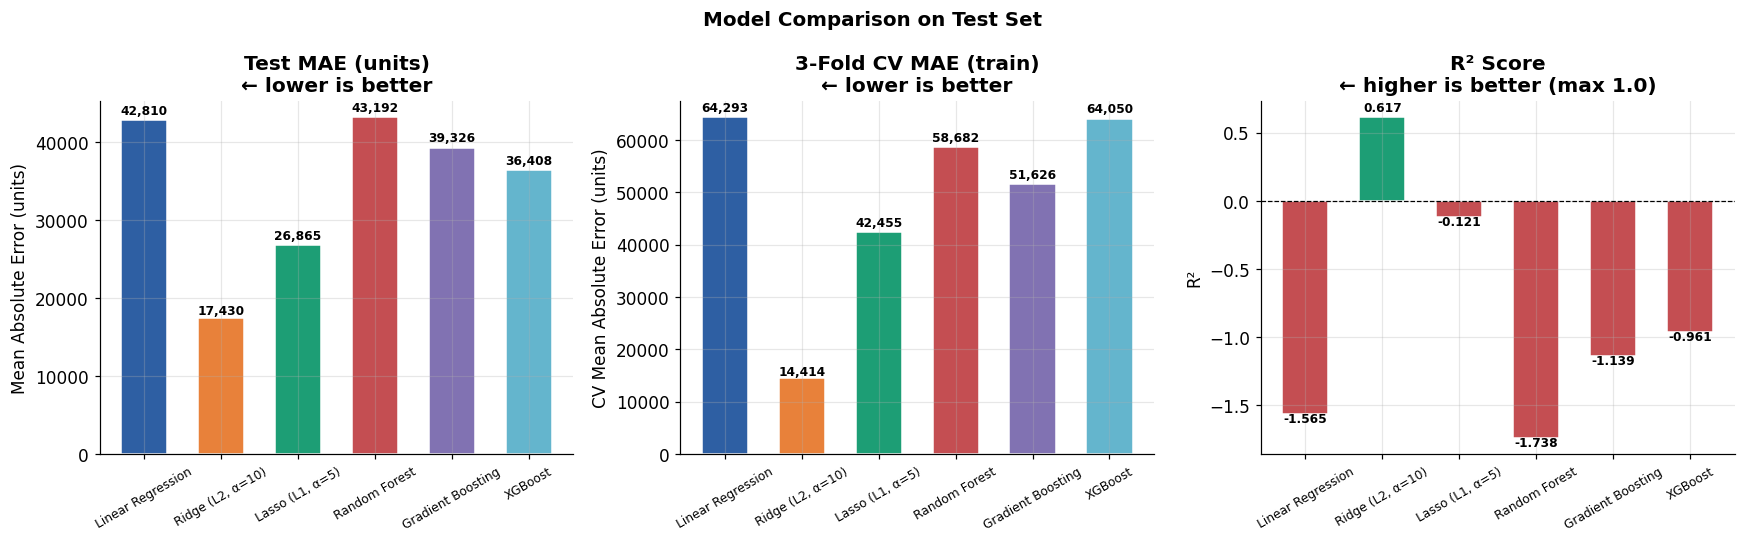

Saved: model_comparison.png


In [13]:
# ── Plot 1: Model comparison bar chart (MAE) ─────────────────────────────────
names  = [v["name"] for v in results.values()]
maes   = [v["mae"]  for v in results.values()]
cv_maes= [v["cv_mae"] for v in results.values()]
r2s    = [v["r2"]   for v in results.values()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison on Test Set", fontsize=13, fontweight="bold")

# MAE
bars = axes[0].bar(names, maes, color=PALETTE[:len(names)], edgecolor="white", width=0.6)
axes[0].set_title("Test MAE (units)\n← lower is better", fontweight="bold")
axes[0].set_ylabel("Mean Absolute Error (units)")
axes[0].tick_params(axis="x", rotation=30, labelsize=8)
for bar, v in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, v * 1.01,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# CV-MAE
bars2 = axes[1].bar(names, cv_maes, color=PALETTE[:len(names)], edgecolor="white", width=0.6)
axes[1].set_title("3-Fold CV MAE (train)\n← lower is better", fontweight="bold")
axes[1].set_ylabel("CV Mean Absolute Error (units)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
for bar, v in zip(bars2, cv_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, v * 1.01,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# R²
colors_r2 = ["#1D9E75" if v >= 0 else "#C44E52" for v in r2s]
bars3 = axes[2].bar(names, r2s, color=colors_r2, edgecolor="white", width=0.6)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("R² Score\n← higher is better (max 1.0)", fontweight="bold")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=30, labelsize=8)
for bar, v in zip(bars3, r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v + 0.02 if v >= 0 else v - 0.08,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")


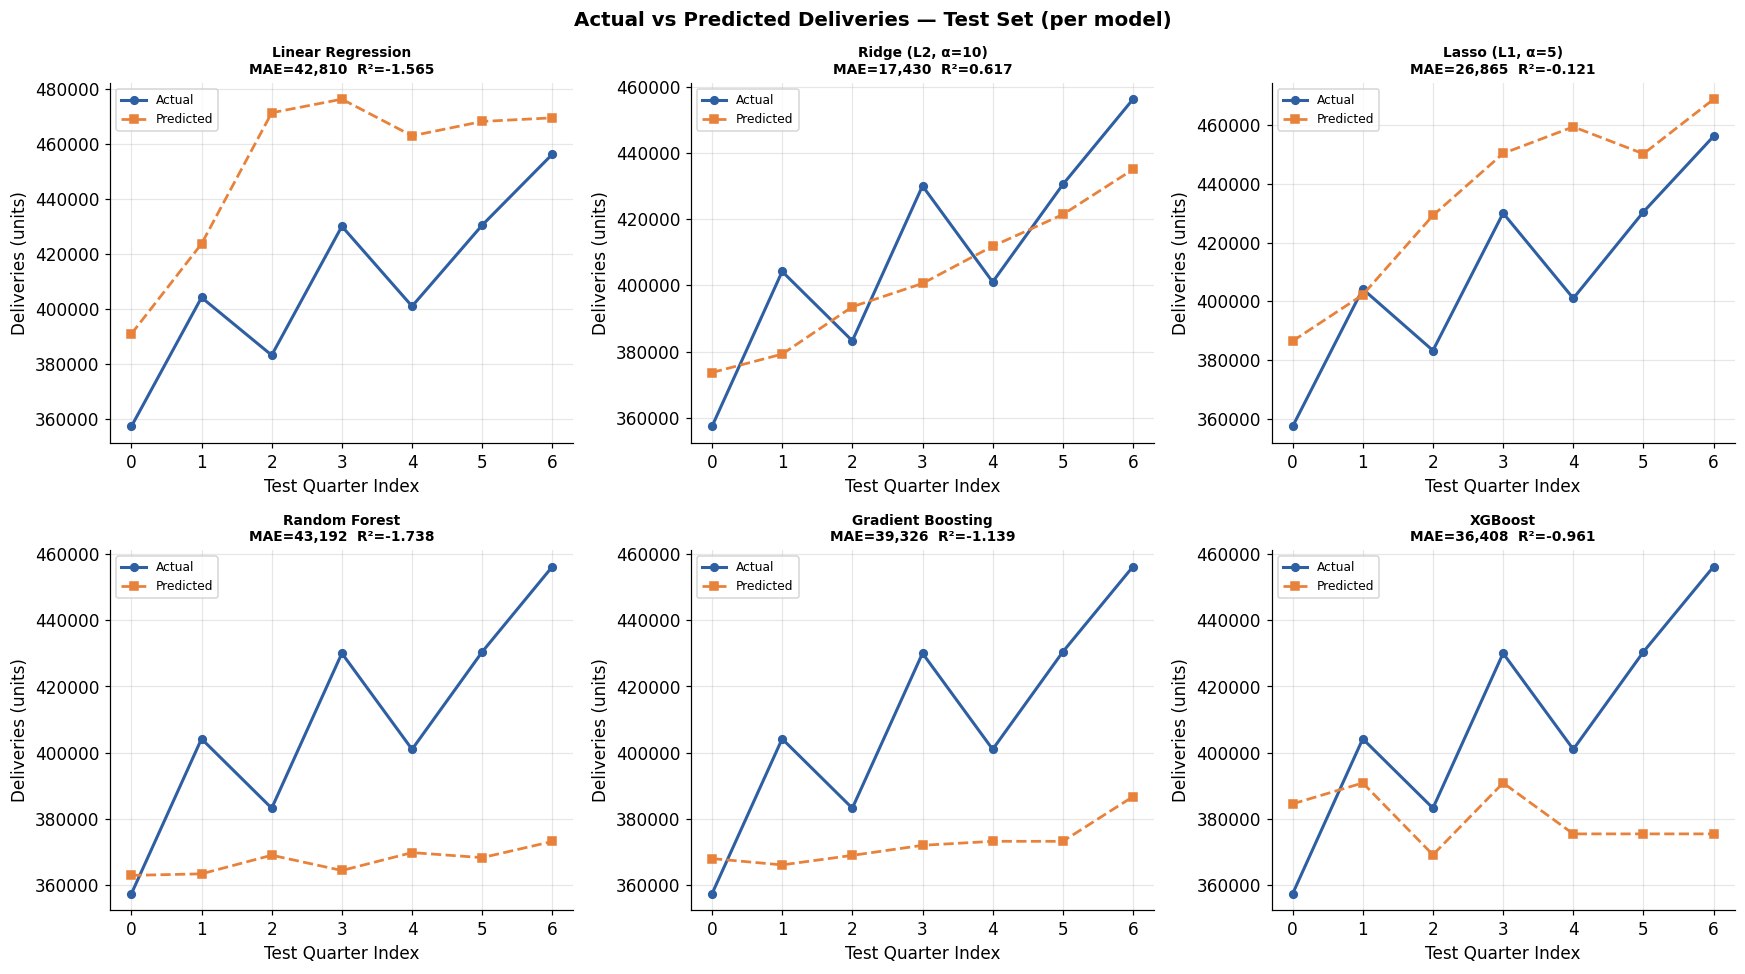

Saved: actual_vs_predicted_all.png

★  Best model: Ridge (L2, α=10)  | MAE 17,430  | R² 0.617


In [14]:
# ── Plot 2: Actual vs Predicted for every model ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Actual vs Predicted Deliveries — Test Set (per model)", fontsize=13, fontweight="bold")

x_idx = np.arange(len(y_test))

for ax, (key, res) in zip(axes.flat, results.items()):
    ax.plot(x_idx, y_test,    label="Actual",    color="#2E5FA3", linewidth=2.0, marker="o", markersize=5)
    ax.plot(x_idx, res["pred"], label="Predicted", color="#E8813A", linewidth=1.8,
            linestyle="--", marker="s", markersize=5)
    ax.set_title(
        f"{res['name']}\nMAE={res['mae']:,.0f}  R²={res['r2']:.3f}",
        fontsize=9, fontweight="bold"
    )
    ax.set_xlabel("Test Quarter Index")
    ax.set_ylabel("Deliveries (units)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted_all.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: actual_vs_predicted_all.png")

best_key  = min(results, key=lambda k: results[k]["mae"])
best_name = results[best_key]["name"]
print(f"\n★  Best model: {best_name}  "
      f"| MAE {results[best_key]['mae']:,.0f}  "
      f"| R² {results[best_key]['r2']:.3f}")


In [15]:
# ── 6.1  GridSearchCV on XGBoost ────────────────────────────────────────────
param_grid = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.10],
    "max_depth":     [3, 5],
    "subsample":     [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    xgb.XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    verbose=0,
)
xgb_gs.fit(X_train, y_train)

best_xgb      = xgb_gs.best_estimator_
y_pred_tuned  = best_xgb.predict(X_test)
tuned_mae     = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse    = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2      = r2_score(y_test, y_pred_tuned)

print("=== GridSearchCV — Best Parameters ===")
for k, v in xgb_gs.best_params_.items():
    print(f"  {k:<18}: {v}")

untuned_mae = results["XGB"]["mae"]
improvement  = (untuned_mae - tuned_mae) / untuned_mae * 100

print(f"\n=== Tuning Impact on MAE ===")
print(f"  Untuned XGBoost : {untuned_mae:>10,.0f} units")
print(f"  Tuned   XGBoost : {tuned_mae:>10,.0f} units")
print(f"  Improvement     : {improvement:>9.1f} %")
print(f"  R²              : {tuned_r2:.4f}")


=== GridSearchCV — Best Parameters ===
  learning_rate     : 0.1
  max_depth         : 3
  n_estimators      : 200
  subsample         : 0.8

=== Tuning Impact on MAE ===
  Untuned XGBoost :     36,408 units
  Tuned   XGBoost :     34,258 units
  Improvement     :       5.9 %
  R²              : -0.7212


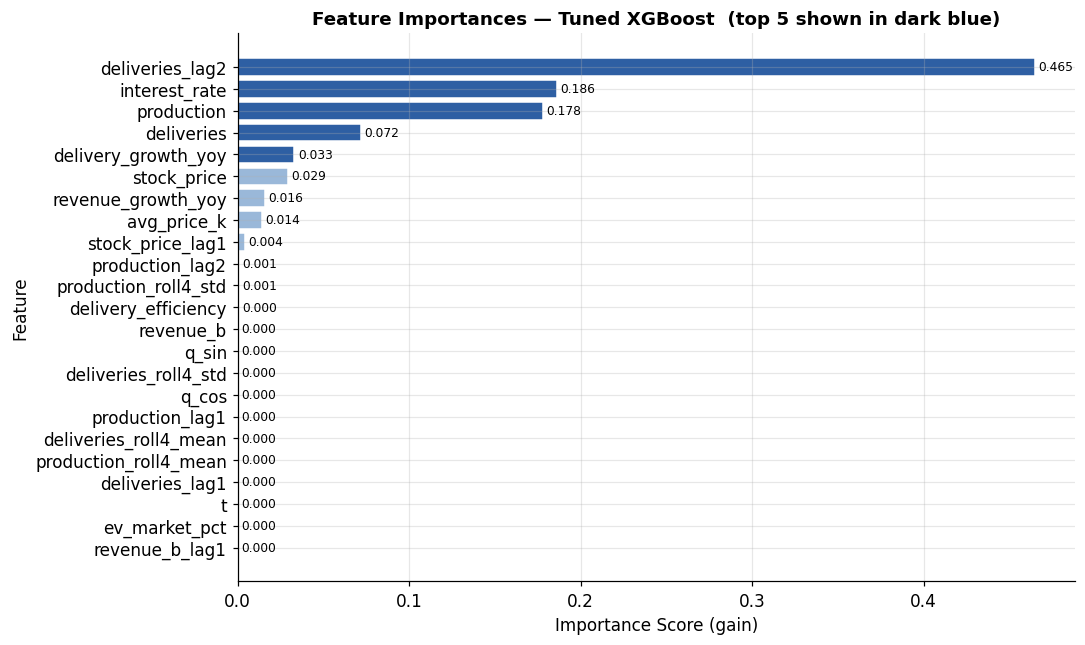

Saved: feature_importance.png

Top 5 features:
deliveries_lag2        0.4649
interest_rate          0.1863
production             0.1782
deliveries             0.0717
delivery_growth_yoy    0.0331


In [16]:
# ── 6.2  Feature importance plot ─────────────────────────────────────────────
fi = pd.Series(
    best_xgb.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ["#2E5FA3" if i < 5 else "#9AB8D9" for i in range(len(fi))]
ax.barh(fi.index, fi.values, color=colors_fi, edgecolor="white")
ax.set_title("Feature Importances — Tuned XGBoost  (top 5 shown in dark blue)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Importance Score (gain)")
ax.set_ylabel("Feature")
ax.invert_yaxis()

for i, (val, name) in enumerate(zip(fi.values, fi.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")
print(f"\nTop 5 features:\n{fi.head(5).round(4).to_string()}")


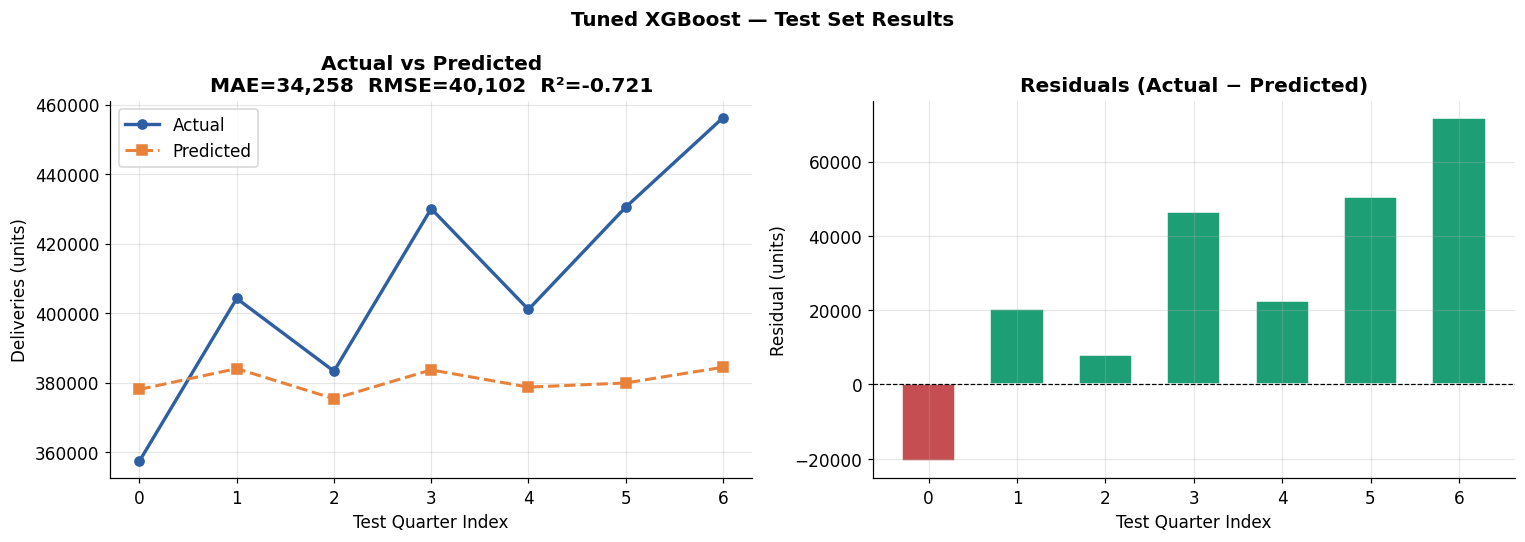

Saved: actual_vs_predicted_tuned.png


In [17]:
# ── 6.3  Actual vs Predicted — Tuned XGBoost ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Tuned XGBoost — Test Set Results", fontsize=13, fontweight="bold")

x_idx = np.arange(len(y_test))

# Line plot
axes[0].plot(x_idx, y_test,       label="Actual",    color="#2E5FA3", linewidth=2.2, marker="o", markersize=6)
axes[0].plot(x_idx, y_pred_tuned, label="Predicted", color="#E8813A", linewidth=2.0,
             linestyle="--", marker="s", markersize=6)
axes[0].set_title(f"Actual vs Predicted\nMAE={tuned_mae:,.0f}  RMSE={tuned_rmse:,.0f}  R²={tuned_r2:.3f}",
                  fontweight="bold")
axes[0].set_xlabel("Test Quarter Index")
axes[0].set_ylabel("Deliveries (units)")
axes[0].legend()

# Residuals
residuals = y_test - y_pred_tuned
axes[1].bar(x_idx, residuals, color=["#1D9E75" if r >= 0 else "#C44E52" for r in residuals],
            edgecolor="white", width=0.6)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals (Actual − Predicted)", fontweight="bold")
axes[1].set_xlabel("Test Quarter Index")
axes[1].set_ylabel("Residual (units)")

plt.tight_layout()
plt.savefig("actual_vs_predicted_tuned.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: actual_vs_predicted_tuned.png")


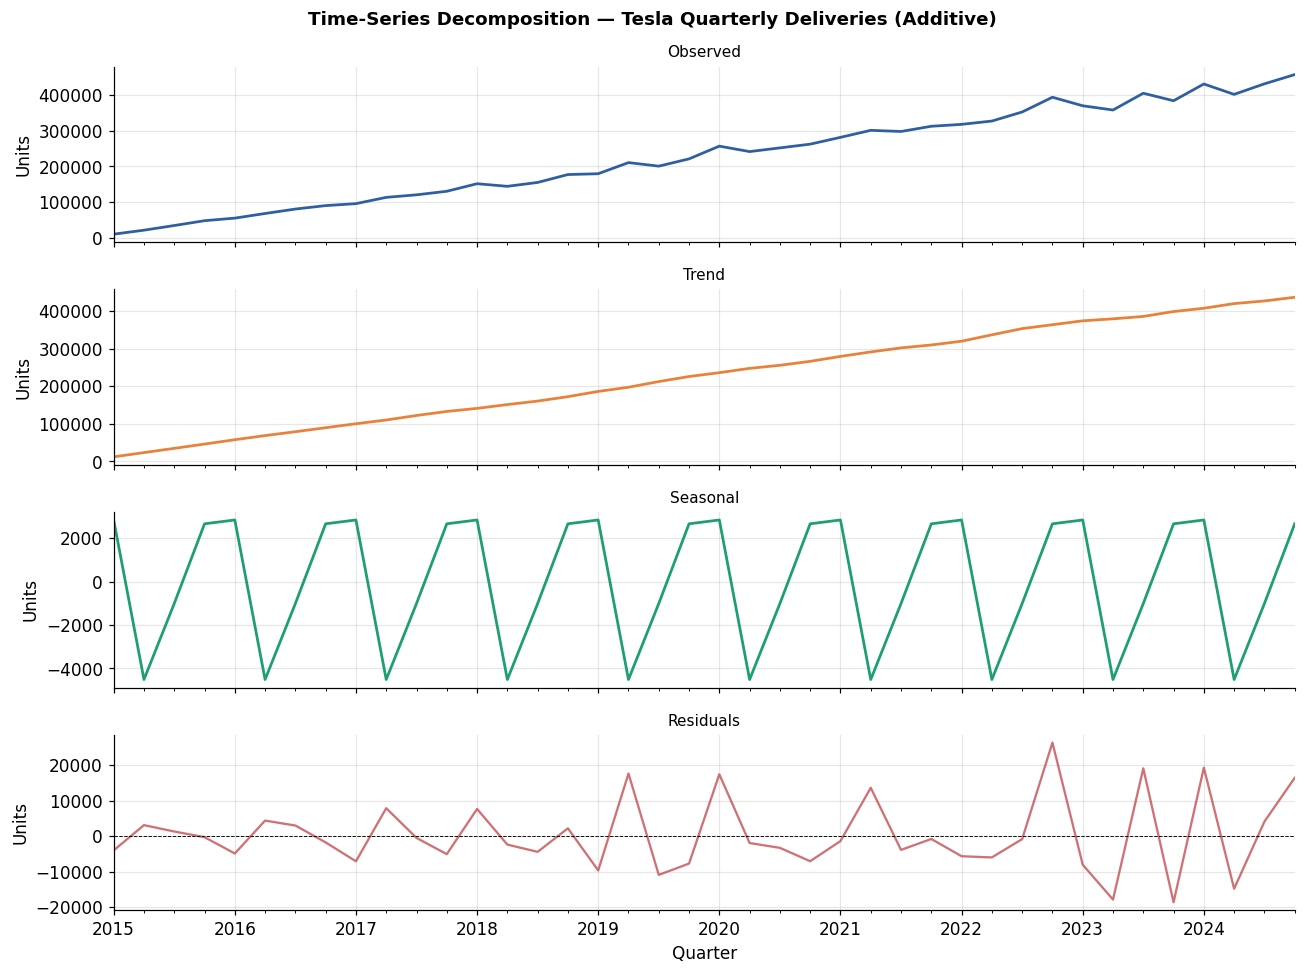

Saved: ts_decomposition.png


In [18]:
ts = df["deliveries"].astype(float)

# ── 7.1  Decomposition plot ──────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts, model="additive", period=4, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Time-Series Decomposition — Tesla Quarterly Deliveries (Additive)",
             fontsize=12, fontweight="bold")

decomp.observed.plot(ax=axes[0],  color="#2E5FA3", linewidth=1.8)
axes[0].set_title("Observed",   fontsize=10); axes[0].set_ylabel("Units")

decomp.trend.plot(ax=axes[1],     color="#E8813A", linewidth=1.8)
axes[1].set_title("Trend",      fontsize=10); axes[1].set_ylabel("Units")

decomp.seasonal.plot(ax=axes[2],  color="#1D9E75", linewidth=1.8)
axes[2].set_title("Seasonal",   fontsize=10); axes[2].set_ylabel("Units")

decomp.resid.plot(ax=axes[3],     color="#C44E52", linewidth=1.5, alpha=0.8)
axes[3].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[3].set_title("Residuals",  fontsize=10); axes[3].set_ylabel("Units")
axes[3].set_xlabel("Quarter")

plt.tight_layout()
plt.savefig("ts_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: ts_decomposition.png")


In [19]:
# ── 7.2  ADF stationarity test ───────────────────────────────────────────────
adf_stat, adf_p, n_lags, n_obs, crit, icbest = adfuller(ts)

print("=== Augmented Dickey-Fuller Test ===")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.6f}")
print(f"  Lags used     : {n_lags}")
print(f"  Observations  : {n_obs}")
for key, val in crit.items():
    print(f"  Critical ({key}) : {val:.4f}")

verdict = "NON-STATIONARY" if adf_p > 0.05 else "STATIONARY"
action  = ("→ Apply first-differencing (d=1) in SARIMA" if adf_p > 0.05
           else "→ Series is ready for modelling as-is")
print(f"\n  Conclusion    : {verdict}  (p {'>' if adf_p > 0.05 else '<='} 0.05)")
print(f"  Action        : {action}")

# ADF on first-differenced series
ts_diff = ts.diff().dropna()
adf_diff = adfuller(ts_diff)
print(f"\n  ADF on first-differenced series: p = {adf_diff[1]:.6f}"
      f"  → {'STATIONARY ✓' if adf_diff[1] < 0.05 else 'still non-stationary'}")


=== Augmented Dickey-Fuller Test ===
  ADF Statistic : 0.1303
  p-value       : 0.968071
  Lags used     : 10
  Observations  : 29
  Critical (1%) : -3.6791
  Critical (5%) : -2.9679
  Critical (10%) : -2.6232

  Conclusion    : NON-STATIONARY  (p > 0.05)
  Action        : → Apply first-differencing (d=1) in SARIMA

  ADF on first-differenced series: p = 0.013217  → STATIONARY ✓


In [20]:
# ── 7.3  Holt-Winters ────────────────────────────────────────────────────────
hw_model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=4,
)
hw_fit = hw_model.fit(optimized=True)
hw_fc  = hw_fit.forecast(4)

print("=== Holt-Winters Smoothing Parameters ===")
print(f"  α (level)    : {hw_fit.params['smoothing_level']:.4f}")
print(f"  β (trend)    : {hw_fit.params['smoothing_trend']:.4f}")
print(f"  γ (seasonal) : {hw_fit.params['smoothing_seasonal']:.4f}")

# ── 7.4  SARIMA (1,1,1)(1,1,0,4) ────────────────────────────────────────────
sarima_model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 4),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
sarima_fc  = sarima_fit.forecast(4)
sarima_ci  = sarima_fit.get_forecast(4).conf_int()

future_idx = pd.date_range("2025-01-01", periods=4, freq="QS")

print("\n=== 2025 Quarterly Forecast ===")
fc_df = pd.DataFrame({
    "Holt-Winters": hw_fc.values.astype(int),
    "SARIMA":       sarima_fc.values.astype(int),
    "SARIMA_CI_lo": sarima_ci.iloc[:, 0].values.astype(int),
    "SARIMA_CI_hi": sarima_ci.iloc[:, 1].values.astype(int),
}, index=["Q1 2025", "Q2 2025", "Q3 2025", "Q4 2025"])
fc_df["Ensemble_Avg"] = ((fc_df["Holt-Winters"] + fc_df["SARIMA"]) / 2).astype(int)
print(fc_df.to_string())


=== Holt-Winters Smoothing Parameters ===
  α (level)    : 0.2070
  β (trend)    : 0.0000
  γ (seasonal) : 0.0425

=== 2025 Quarterly Forecast ===
         Holt-Winters  SARIMA  SARIMA_CI_lo  SARIMA_CI_hi  Ensemble_Avg
Q1 2025        455415  459599        416902        502296        457507
Q2 2025        464817  441141        398389        483894        452979
Q3 2025        475717  481245        437102        525389        478481
Q4 2025        488995  478287        433221        523354        483641


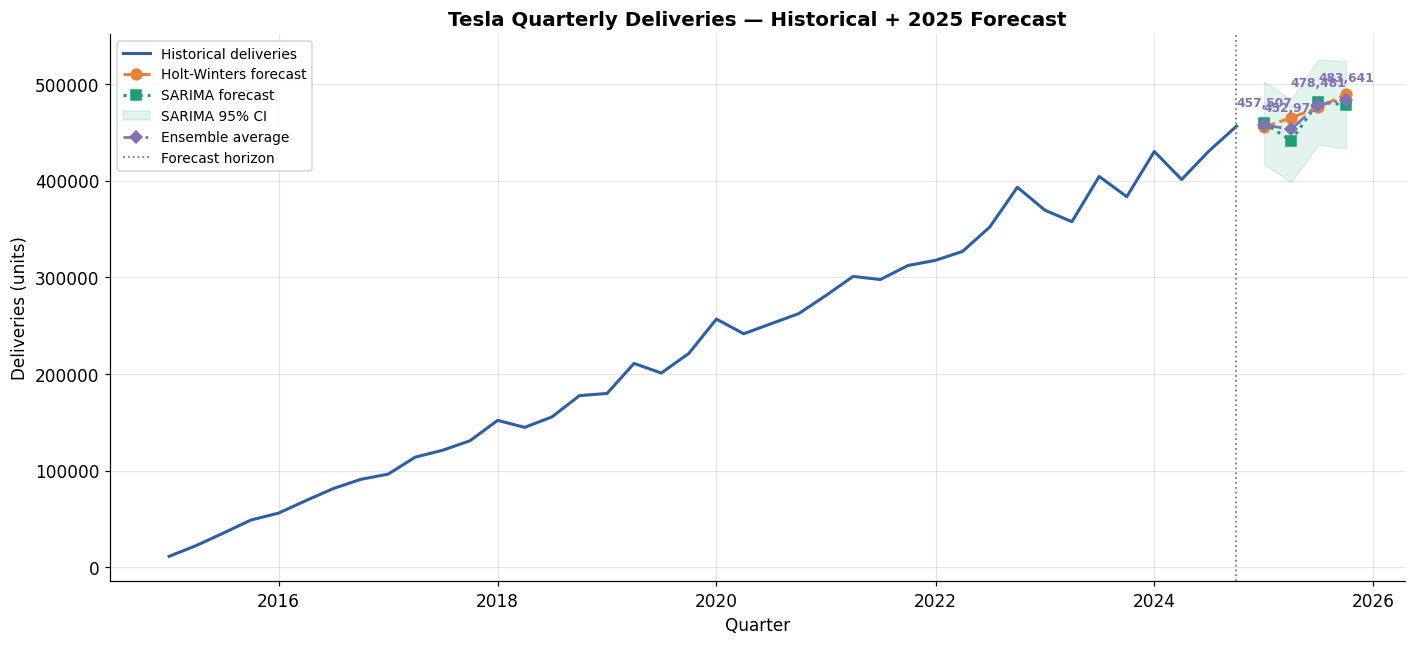

Saved: timeseries_forecast.png


In [21]:
# ── 7.5  Forecast plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

# Historical
ax.plot(ts.index, ts.values, color="#2E5FA3", linewidth=2.0, label="Historical deliveries")

# Holt-Winters forecast
ax.plot(future_idx, hw_fc.values, color="#E8813A", linewidth=2.0,
        linestyle="--", marker="o", markersize=7, label="Holt-Winters forecast")

# SARIMA forecast + CI
ax.plot(future_idx, sarima_fc.values, color="#1D9E75", linewidth=2.0,
        linestyle=":", marker="s", markersize=7, label="SARIMA forecast")
ax.fill_between(future_idx,
                sarima_ci.iloc[:, 0].values,
                sarima_ci.iloc[:, 1].values,
                color="#1D9E75", alpha=0.12, label="SARIMA 95% CI")

# Ensemble average
ax.plot(future_idx, fc_df["Ensemble_Avg"].values, color="#8172B2", linewidth=1.8,
        linestyle="-.", marker="D", markersize=6, label="Ensemble average")

# Divider
ax.axvline(ts.index[-1], color="grey", linewidth=1.2, linestyle=":", label="Forecast horizon")

# Annotations
for i, idx in enumerate(future_idx):
    ax.annotate(f"{fc_df['Ensemble_Avg'].iloc[i]:,}",
                xy=(idx, fc_df["Ensemble_Avg"].iloc[i]),
                xytext=(0, 12), textcoords="offset points",
                ha="center", fontsize=8, color="#8172B2", fontweight="bold")

ax.set_title("Tesla Quarterly Deliveries — Historical + 2025 Forecast",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Deliveries (units)")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("timeseries_forecast.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: timeseries_forecast.png")


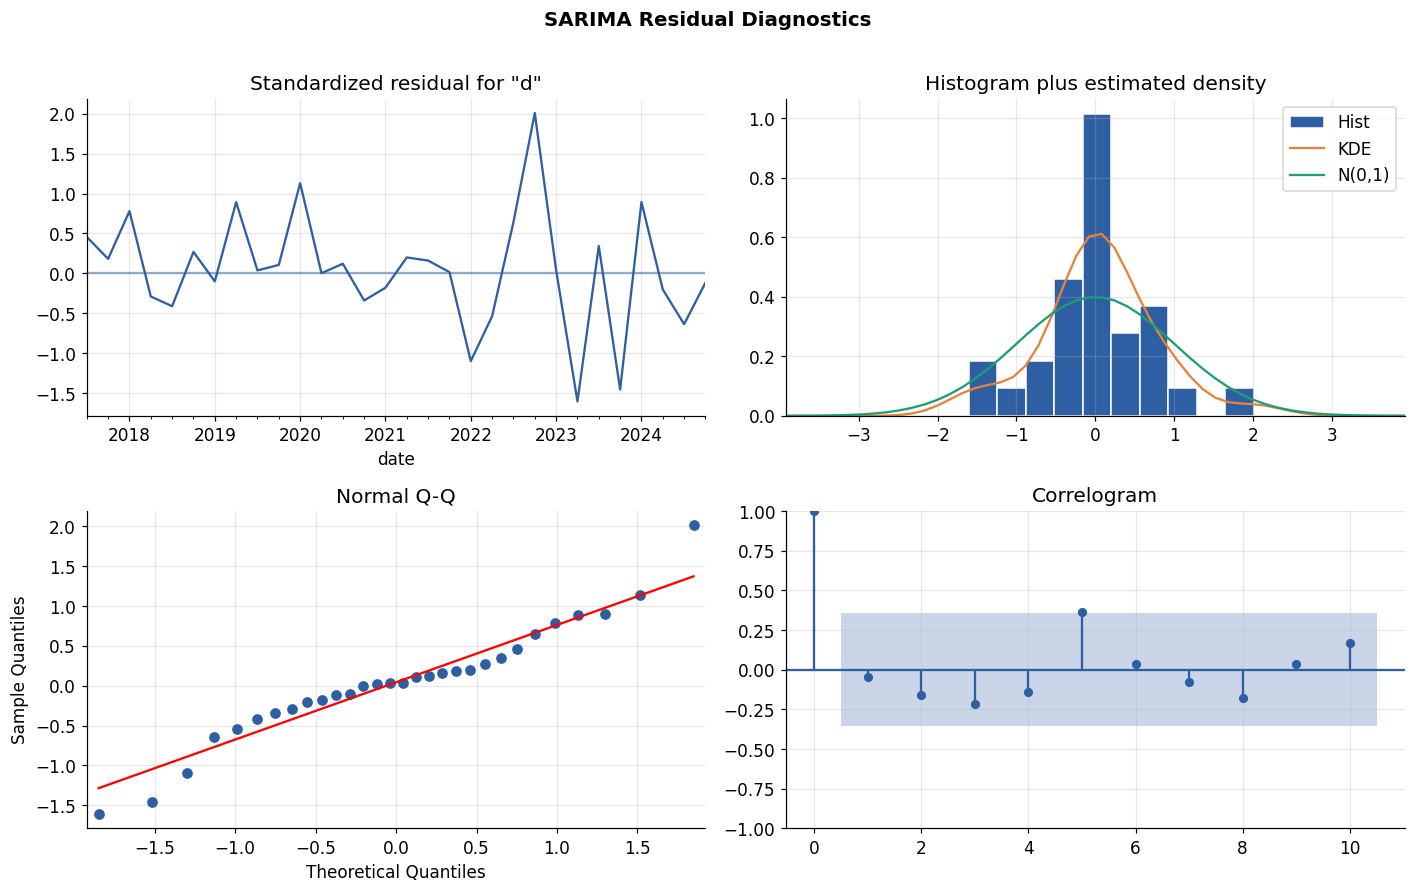

Saved: sarima_residuals.png


In [22]:
# ── 7.6  SARIMA residual diagnostics ─────────────────────────────────────────
fig = sarima_fit.plot_diagnostics(figsize=(13, 8))
fig.suptitle("SARIMA Residual Diagnostics", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sarima_residuals.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: sarima_residuals.png")


In [23]:
# ── Final summary printout ────────────────────────────────────────────────────
best_model   = min(results, key=lambda k: results[k]["mae"])
best_metrics = results[best_model]

print("=" * 58)
print("  PIPELINE COMPLETE — FINAL SUMMARY")
print("=" * 58)
print(f"  Dataset          : Tesla EA 2015–2024  (40 quarters)")
print(f"  Raw features     : 12")
print(f"  Engineered feats : {len(FEATURES)}")
print(f"  Training rows    : {X_train.shape[0]}")
print(f"  Test rows        : {X_test.shape[0]}")
print()
print(f"  Best regression model : {best_metrics['name']}")
print(f"    MAE  = {best_metrics['mae']:>10,.0f} units")
print(f"    RMSE = {best_metrics['rmse']:>10,.0f} units")
print(f"    R²   = {best_metrics['r2']:>10.4f}")
print()
print(f"  Tuned XGBoost MAE : {tuned_mae:>10,.0f} units  (↓ {(results['XGB']['mae']-tuned_mae)/results['XGB']['mae']*100:.1f}% from baseline)")
print()
print("  2025 Forecast (ensemble average):")
for q, v in zip(["Q1","Q2","Q3","Q4"], fc_df["Ensemble_Avg"].values):
    bar = "█" * int(v / 20_000)
    print(f"    {q}: {v:>7,} units  {bar}")
print("=" * 58)


  PIPELINE COMPLETE — FINAL SUMMARY
  Dataset          : Tesla EA 2015–2024  (40 quarters)
  Raw features     : 12
  Engineered feats : 23
  Training rows    : 28
  Test rows        : 7

  Best regression model : Ridge (L2, α=10)
    MAE  =     17,430 units
    RMSE =     18,928 units
    R²   =     0.6165

  Tuned XGBoost MAE :     34,258 units  (↓ 5.9% from baseline)

  2025 Forecast (ensemble average):
    Q1: 457,507 units  ██████████████████████
    Q2: 452,979 units  ██████████████████████
    Q3: 478,481 units  ███████████████████████
    Q4: 483,641 units  ████████████████████████
